In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("Quotation_Cost_Prediction.csv")

In [3]:
dataset

,Project_ID,Building_Type,Floors,Foundation_Type,Builtup_Area_sqft,Cement_Bags,Steel_MT,Sand_Cum,Aggregate_Cum,Brick_Qty,Labour_Cost,Material_Cost,Equipment_Cost,Overhead,Profit_Percentage,GST,Location,Project_Duration_Days,Final_Quotation
0,PR0001,Residential,G,Isolated,1200,180,6.2,52,48,14000,320000,980000,75000,110000,12,18,Chennai,75,1669700
1,PR0002,Residential,G+1,Isolated,1800,260,9.5,78,70,22000,510000,1540000,98000,170000,12,18,Madurai,95,2620760
2,PR0003,Commercial,G+2,Raft,4500,620,22.4,180,170,54000,1250000,4120000,225000,460000,15,18,Chennai,150,7133100
3,PR0004,Industrial,G+1,Pile,8000,1100,48.5,340,315,92000,2150000,7580000,420000,810000,15,18,Coimbatore,210,12974200
4,PR0005,PEB,G,Combined,10000,980,62.5,360,335,60000,1850000,8120000,510000,900000,14,18,Chennai,160,13593680
5,PR0006,Residential,G+2,Raft,2500,340,12.8,105,96,32000,720000,2180000,145000,240000,12,18,Trichy,120,3824360
6,PR0007,Commercial,G+3,Pile,6000,820,34.6,245,228,76000,1680000,5780000,325000,650000,15,18,Chennai,180,10071300
7,PR0008,Industrial,G+2,Raft,9500,1280,56.2,390,365,108000,2450000,8960000,620000,980000,15,18,Madurai,240,15056840
8,PR0009,Residential,G+1,Combined,2100,295,10.6,88,82,26000,590000,1750000,120000,190000,12,18,Coimbatore,105,3020800
9,PR0010,Commercial,G+1,Isolated,3800,520,18.4,155,146,47000,1080000,3520000,210000,380000,14,18,Chennai,145,6058120


In [4]:
dataset = pd.get_dummies(
    dataset,
    columns=["Building_Type", "Floors", "Foundation_Type", "Location"],
    drop_first=True)


In [5]:
dataset.columns

Index(['Project_ID', 'Builtup_Area_sqft', 'Cement_Bags', 'Steel_MT',
       'Sand_Cum', 'Aggregate_Cum', 'Brick_Qty', 'Labour_Cost',
       'Material_Cost', 'Equipment_Cost', 'Overhead', 'Profit_Percentage',
       'GST', 'Project_Duration_Days', 'Final_Quotation',
       'Building_Type_Industrial', 'Building_Type_PEB',
       'Building_Type_Residential', 'Floors_G+1', 'Floors_G+2', 'Floors_G+3',
       'Foundation_Type_Isolated', 'Foundation_Type_Pile',
       'Foundation_Type_Raft', 'Location_Coimbatore', 'Location_Madurai',
       'Location_Salem', 'Location_Trichy'],
      dtype='object')

In [6]:
Independent=dataset[['Builtup_Area_sqft', 'Cement_Bags', 'Steel_MT', 'Sand_Cum',
       'Aggregate_Cum', 'Brick_Qty', 'Labour_Cost', 'Material_Cost',
       'Equipment_Cost', 'Overhead', 'Profit_Percentage', 'GST',
       'Project_Duration_Days','Building_Type_Industrial',
       'Building_Type_PEB', 'Building_Type_Residential', 'Floors_G+1',
       'Floors_G+2', 'Floors_G+3', 'Foundation_Type_Isolated',
       'Foundation_Type_Pile', 'Foundation_Type_Raft', 'Location_Coimbatore',
       'Location_Madurai', 'Location_Salem', 'Location_Trichy']]

In [7]:
Independent

,Builtup_Area_sqft,Cement_Bags,Steel_MT,Sand_Cum,Aggregate_Cum,Brick_Qty,Labour_Cost,Material_Cost,Equipment_Cost,Overhead,...,Floors_G+1,Floors_G+2,Floors_G+3,Foundation_Type_Isolated,Foundation_Type_Pile,Foundation_Type_Raft,Location_Coimbatore,Location_Madurai,Location_Salem,Location_Trichy
0,1200,180,6.2,52,48,14000,320000,980000,75000,110000,...,0,0,0,1,0,0,0,0,0,0
1,1800,260,9.5,78,70,22000,510000,1540000,98000,170000,...,1,0,0,1,0,0,0,1,0,0
2,4500,620,22.4,180,170,54000,1250000,4120000,225000,460000,...,0,1,0,0,0,1,0,0,0,0
3,8000,1100,48.5,340,315,92000,2150000,7580000,420000,810000,...,1,0,0,0,1,0,1,0,0,0
4,10000,980,62.5,360,335,60000,1850000,8120000,510000,900000,...,0,0,0,0,0,0,0,0,0,0
5,2500,340,12.8,105,96,32000,720000,2180000,145000,240000,...,0,1,0,0,0,1,0,0,0,1
6,6000,820,34.6,245,228,76000,1680000,5780000,325000,650000,...,0,0,1,0,1,0,0,0,0,0
7,9500,1280,56.2,390,365,108000,2450000,8960000,620000,980000,...,0,1,0,0,0,1,0,1,0,0
8,2100,295,10.6,88,82,26000,590000,1750000,120000,190000,...,1,0,0,0,0,0,1,0,0,0
9,3800,520,18.4,155,146,47000,1080000,3520000,210000,380000,...,1,0,0,1,0,0,0,0,0,0


In [8]:
dependent=dataset[["Final_Quotation"]]

In [9]:
dependent

,Final_Quotation
0,1669700
1,2620760
2,7133100
3,12974200
4,13593680
5,3824360
6,10071300
7,15056840
8,3020800
9,6058120


In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(Independent,dependent,test_size=0.3,random_state=0)

In [11]:
x_train

,Builtup_Area_sqft,Cement_Bags,Steel_MT,Sand_Cum,Aggregate_Cum,Brick_Qty,Labour_Cost,Material_Cost,Equipment_Cost,Overhead,...,Floors_G+1,Floors_G+2,Floors_G+3,Foundation_Type_Isolated,Foundation_Type_Pile,Foundation_Type_Raft,Location_Coimbatore,Location_Madurai,Location_Salem,Location_Trichy
4,10000,980,62.5,360,335,60000,1850000,8120000,510000,900000,...,0,0,0,0,0,0,0,0,0,0
2,4500,620,22.4,180,170,54000,1250000,4120000,225000,460000,...,0,1,0,0,0,1,0,0,0,0
13,5200,710,28.6,210,198,62000,1420000,4850000,285000,520000,...,0,1,0,0,0,0,0,1,0,0
10,1400,205,7.1,58,54,16500,360000,1100000,82000,120000,...,0,0,0,1,0,0,0,0,1,0
7,9500,1280,56.2,390,365,108000,2450000,8960000,620000,980000,...,0,1,0,0,0,1,0,1,0,0
11,15000,1980,96.5,620,590,170000,3950000,14500000,920000,1600000,...,0,0,1,0,1,0,0,0,0,0
3,8000,1100,48.5,340,315,92000,2150000,7580000,420000,810000,...,1,0,0,0,1,0,1,0,0,0
0,1200,180,6.2,52,48,14000,320000,980000,75000,110000,...,0,0,0,1,0,0,0,0,0,0
5,2500,340,12.8,105,96,32000,720000,2180000,145000,240000,...,0,1,0,0,0,1,0,0,0,1
12,8500,920,54.8,310,295,58000,1750000,7350000,430000,760000,...,0,0,0,0,0,1,0,0,0,1


In [12]:
from sklearn.ensemble import RandomForestRegressor
regressor=RandomForestRegressor(n_estimators=50,random_state=0)
regressor.fit(x_train,y_train)

C:\Users\SPPSS\anaconda3\envs\aiml\lib\site-packages\ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


RandomForestRegressor(n_estimators=50, random_state=0)

In [13]:
y_pred=regressor.predict(x_test)

In [14]:
from sklearn.metrics import r2_score


In [15]:
r_score=r2_score(y_test,y_pred)
r_score

0.9872534088311499

In [16]:
import pickle 
filename="Finalized_model_Random_Forest_Cost.sav"
pickle.dump(regressor,open(filename,'wb'))

In [26]:
loaded_model=pickle.load(open("Finalized_model_Random_Forest_Cost.sav",'rb'))
result=loaded_model.predict([[1200,260,9.5,78,70,22000,510000,1040000,98000,170000,12,18,95,0,0,1,1,0,0,1,0,0,0,1,0,0
]])

C:\Users\SPPSS\anaconda3\envs\aiml\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  "X does not have valid feature names, but"


In [27]:
result

array([2271284.])

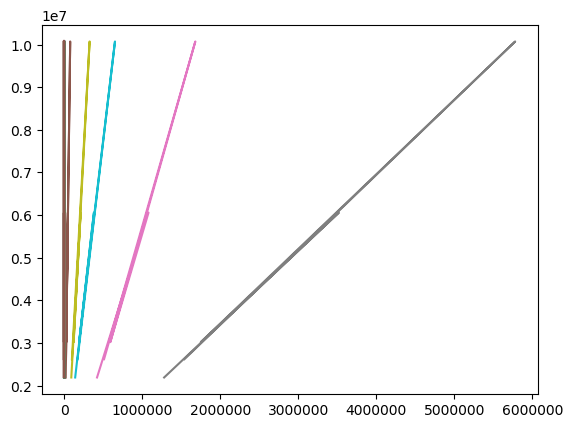

In [19]:
import numpy as np
import matplotlib.pyplot as plt
plt.plot(x_test, y_test)
plt.show()

In [20]:
result1 = pd.DataFrame({
    
    'Actual': y_test.iloc[:, 0],  
    'Predicted': y_pred.flatten() if hasattr(y_pred, 'flatten') else y_pred 
})

print(result1)

      Actual  Predicted
1    2620760  2288872.8
6   10071300  9816010.0
8    3020800  3041685.6
9    6058120  6672003.6
14   2192440  2288872.8


In [21]:
x_test.to_csv("x_test_Cost_Prediction.csv",index=False)